In [11]:
#Done
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from efficient_apriori import apriori
import re
params = {
    "axes.labelsize": 15,
    "font.size": 15,
    "legend.fontsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "font.family": "serif",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.top": True,
    "ytick.right": True,
    "xtick.direction": "in",
    "ytick.direction": "in",
}
plt.rcParams.update(params)

In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
datas = pd.read_csv('NASACompositeDataset06122025.csv', comment='#', low_memory=False)
data = pd.DataFrame(data=datas)
#These two were labeled incorrectly on the dataframe
data.replace({ 'st_spectype': {'m3 V':'M V'} }, inplace = True)
data.replace({ 'st_spectype': {'sdBV':'B V'} }, inplace = True)
#print(data.count())
#4673 = m -> M V
#5209 = s -> B V

In [4]:
#estimates the semimajor axis given a row of a data frame given stellar mass and orbital period: Kepler's 3rd law
#Only estimates the semimajor axis if the value is originally NaN
def estimate_orbsmax(row):
    if pd.isna(row['pl_orbsmax']):
        try:
            return (((6.67e-11 * (row['st_mass'] * 1.989e30) * ((row['pl_orbper'] * 86400)**2)) / (4 * (np.pi**2)))**(1/3)) / 1.496e11
        except:
            return np.nan
    else:
        return row['pl_orbsmax']

#Sets the spectral type if it is already in the string for the spectype variable for each row.
#Otherwise, it is estimated based on equillibrium temperature.
def get_spectype(row):
    try: 
        return row['st_spectype'][0]
    except:
        if(row['st_teff']>=30000):
            return 'O'
        elif(row['st_teff']>=10000):
            return 'B'
        elif(row['st_teff']>=7500):
            return 'A'
        elif(row['st_teff']>=6000):
            return 'F'
        elif(row['st_teff']>=5200):
            return 'G'
        elif(row['st_teff']>=3700):
            return 'K'
        elif(row['st_teff']>=2400):
            return 'M'
        else:
            return row['st_spectype']

#Estimates the equillibrium temperature of a row given stellar luminosity, and semimajor axis
#Only estimates if there is a missing value for pl_eqt: Stefan-Boltzmann's law
def estimate_pl_eqt(row):
    if pd.isna(row['pl_eqt']):
        try:
            return (((10 ** row['st_lum']) * 3.827e26) / (16 * np.pi * 5.67e-8 * ((row['pl_orbsmax'] * 1.496e11) ** 2))) ** (1 / 4)
        except:
            return np.nan
    else:
        return row['pl_eqt']
    
#Applying the above functions to the dataframe.
data['pl_orbsmax'] = data.apply(estimate_orbsmax, axis=1)
data['pl_eqt'] = data.apply(estimate_pl_eqt, axis = 1)
data['spectype'] = data.apply(get_spectype, axis = 1)

In [5]:
#Grabs the last value of the string, usually the Luminosity Class of the star
#Otherwise, estimates whethoer or not the star is main sequence based on the luminosity of the star
def is_mainsequence(row):
    if(str(row['st_spectype'])[-1] == ('V') and str(row['st_spectype'])[-2:] != ('IV')):
        return 'True'
    else:
        try:
            if(str(row['spectype']).__contains__('M') and row['st_lum'] < -1.0969):
                return 'True'
            elif(str(row['spectype']).__contains__('K') and row['st_lum'] < -0.2218):
                return 'True'
            elif(str(row['spectype']).__contains__('G') and row['st_lum'] < 0.1761):
                return 'True'
            elif(str(row['spectype']).__contains__('F') and row['st_lum'] < 0.699):
                return 'True'
            elif(str(row['spectype']).__contains__('A') and row['st_lum'] < 1.3979):
                return 'True'
            elif(str(row['spectype']).__contains__('B') and row['st_lum'] < 4.477):
                return 'True'
            elif(str(row['spectype']).__contains__('O')):
                return 'True'
            else:
                return 'False'
        except:
            return 'False'
                


data['isMS'] = data.apply(is_mainsequence, axis = 1)

'for i in mainseqtest.patches:  \n    mainseqtest.annotate(str(i.get_height()), (i.get_x(), i.get_height()))'

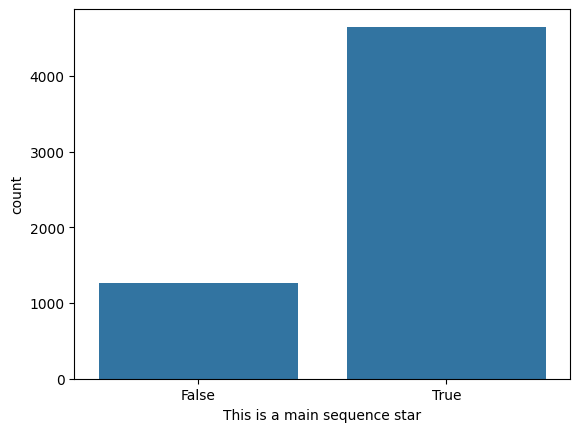

In [6]:
#Testing the ratio of main sequence stars to non-main sequence stars: seems low. Can we improve this?
mainseqtest = sns.countplot(data= data, x ='isMS')
mainseqtest.set(xlabel = 'This is a main sequence star')
'''for i in mainseqtest.patches:  
    mainseqtest.annotate(str(i.get_height()), (i.get_x(), i.get_height()))'''

5061

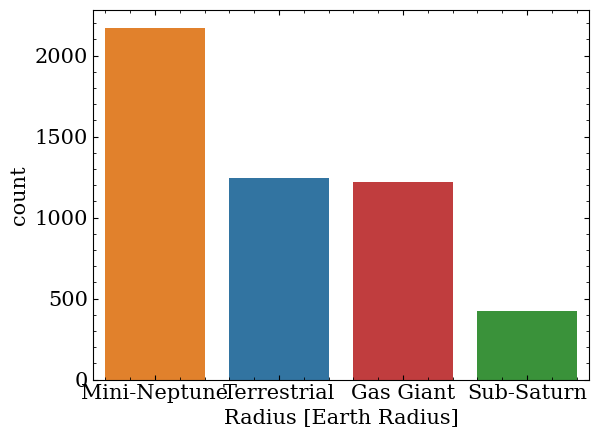

In [12]:
#Remove systems with more that one host star
star = data.loc[data['sy_snum'] == 1]
# Excluded planet systems that did not have any data on the variables of interest
star = star.loc[star['pl_orbper'].isna() == False]
star = star.loc[star['pl_rade'].isna() == False]
star = star.loc[star['st_teff'].isna() == False]
star = star.loc[star['pl_eqt'].isna() == False]
star = star.loc[star['spectype'].isna() == False]

#Divides planets into bins based on radius
star['pl_rad_bin'] = pd.cut(star['pl_rade'], bins = [0, 1.7, 3.9, 9.4, 1000], labels = ['Terrestrial', 'Mini-Neptune', 'Sub-Saturn', 'Gas Giant'])
radius = sns.countplot(data = star, x = 'pl_rad_bin', hue = 'pl_rad_bin', order = star['pl_rad_bin'].value_counts().index)
radius.set_xlabel('Radius [Earth Radius]')
star['pl_rad_bin'].count()
len(star)

/tmp/ipykernel_3135491/2369708736.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  orbitalPeriod.set_xticklabels(orbitalPeriod.get_xticklabels(), rotation=30)


5061

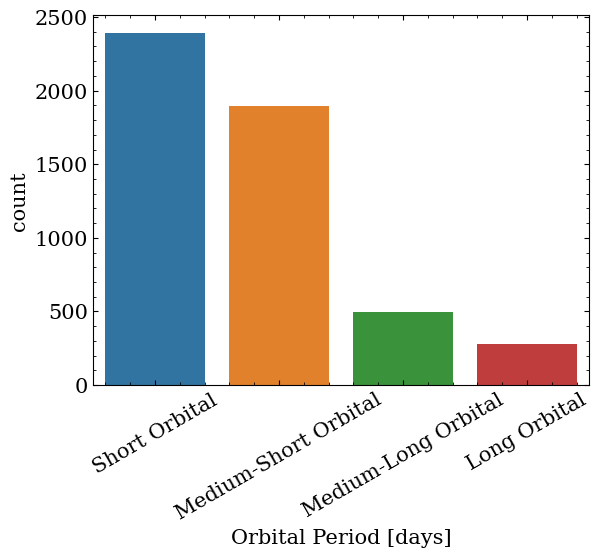

In [13]:
#seporated the planets based on orbital period
star['pl_orb_bin'] = pd.cut(star['pl_orbper'], bins = [0, 10, 100, 1000, 10000000000], labels = ['Short Orbital', 'Medium-Short Orbital', 'Medium-Long Orbital', 'Long Orbital'])
orbitalPeriod = sns.countplot(data = star, x = 'pl_orb_bin', hue = 'pl_orb_bin')
orbitalPeriod.set(xlabel = 'Orbital Period [days]')
orbitalPeriod.set_xticklabels(orbitalPeriod.get_xticklabels(), rotation=30)
star['pl_orb_bin'].count()

Text(0.5, 0, 'Temperature [K]')

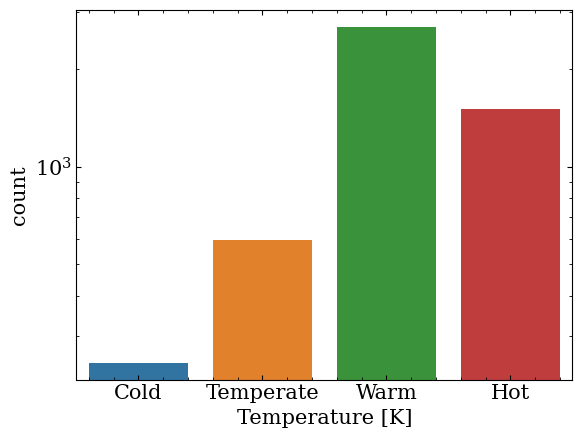

In [14]:
#seporate planets based on equillibrium temperature
star['pl_eqt_bin'] = pd.cut(star['pl_eqt'], bins = [0, 200, 400, 1000, 10000000], labels = ['Cold', 'Temperate', 'Warm', 'Hot'])
temp = sns.countplot(data = star, x = 'pl_eqt_bin', hue = 'pl_eqt_bin')
temp.set_yscale('log')
temp.set_xlabel('Temperature [K]')

/tmp/ipykernel_3135491/2446620803.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  classgraph.set_xticklabels(classgraph.get_xticklabels(), rotation=90)


Text(0.5, 0, 'Classification: temp, size, orbit')

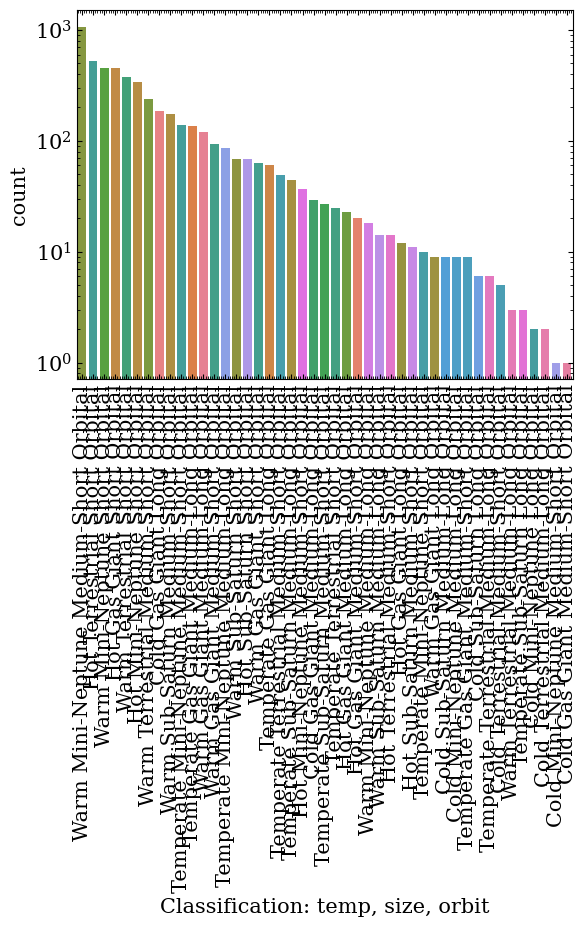

In [15]:
#Split the planets into their designated group based on the previous 3 characteristics: orbital period, temperature, and radius size
star['pl_class'] = star[['pl_eqt_bin','pl_rad_bin', 'pl_orb_bin']].astype('str').agg(" ".join, axis=1)
classgraph = sns.countplot(data = star, x = 'pl_class', hue = 'pl_class', order = star['pl_class'].value_counts().index)
classgraph.set_xticklabels(classgraph.get_xticklabels(), rotation=90)
classgraph.set_yscale('log')
classgraph.set_xlabel('Classification: temp, size, orbit')

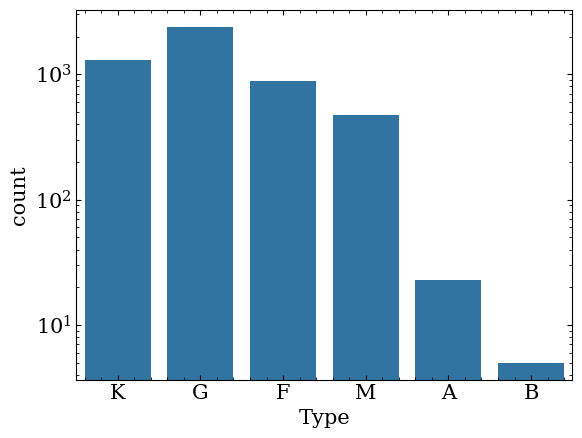

In [16]:
#grouping the planets by their host star
#star['st_class_bin'] = pd.cut(star['st_teff'], bins = [0, 3700, 5200, 6000, 7500, 10000, 30000], labels = ['M', 'K', 'G', 'F','A', 'B'])
stellartype = sns.countplot(data = star, x = 'spectype')
stellartype.set_xlabel('Type')
stellartype.set_yscale('log')
star['spectype'].count()
original = star.groupby(by='hostname')
count = original.count().sort_values(by='pl_name')
#star['st_spectype'].sort_values()
#4673 = m -> MV
#5209 = s -> BV

/tmp/ipykernel_3135491/3415210939.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  sclassgraph.set_xticklabels(sclassgraph.get_xticklabels(), rotation=90, fontsize = 3)


Text(0.5, 0, 'Classification: spec type, temp, size, orbit')

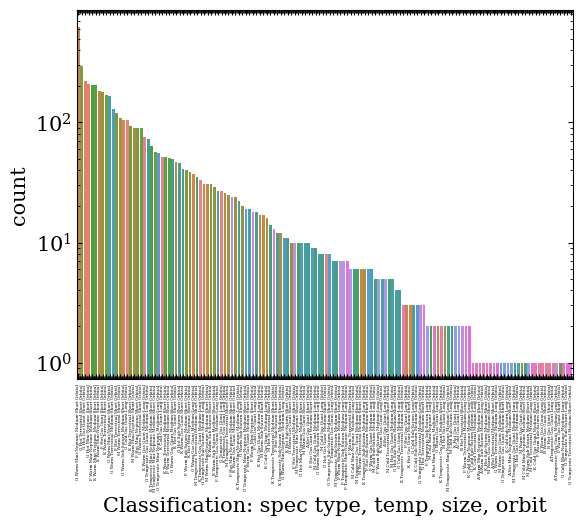

In [18]:
#Puts the planets into the stellar classification
star['stars_class'] = star[['spectype', 'pl_class']].agg(" ".join, axis=1)
sclassgraph = sns.countplot(data = star, x = 'stars_class', hue = 'stars_class', order = star['stars_class'].value_counts().index)
sclassgraph.set_xticklabels(sclassgraph.get_xticklabels(), rotation=90, fontsize = 3)
sclassgraph.set_yscale('log')
sclassgraph.set_xlabel('Classification: spec type, temp, size, orbit')
#data['st_teff'].sort_values()

# Predicting Occurances Using Association Analysis

### Main Sequence Stars, Only looking at planet classification

In [19]:
#Creating a dataframe with only main sequence stars and their proper classificaiton
onlyMS = star.loc[star['isMS'] == 'True']
testMSpl = {'type': onlyMS['pl_class'],'host':onlyMS['hostname']}
testingMSpl = pd.DataFrame(data=testMSpl)
#Put into tuples by host star for the package
baseMSpl = testingMSpl.groupby('host')    
MSplAA = [tuple(baseMSpl.get_group(x)['type']) for x in baseMSpl.groups]

In [20]:
#Performs the association analysis based on the planet classifications.
itemsetMSpl, rulesMSpl = apriori(MSplAA, min_support= 2/len(onlyMS), min_confidence=.5)
print('There are ' + str(rulesMSpl.__len__())+ ' rules.')
rulesMSpl

There are 28 rules.


[{Cold Terrestrial Medium-Short Orbital} -> {Temperate Terrestrial Medium-Short Orbital},
 {Cold Terrestrial Medium-Short Orbital} -> {Temperate Terrestrial Short Orbital},
 {Warm Sub-Saturn Medium-Long Orbital} -> {Warm Mini-Neptune Medium-Short Orbital},
 {Cold Gas Giant Medium-Long Orbital, Warm Mini-Neptune Short Orbital} -> {Cold Gas Giant Long Orbital},
 {Cold Gas Giant Long Orbital, Warm Mini-Neptune Short Orbital} -> {Cold Gas Giant Medium-Long Orbital},
 {Cold Gas Giant Long Orbital, Temperate Mini-Neptune Medium-Long Orbital} -> {Warm Mini-Neptune Medium-Short Orbital},
 {Cold Gas Giant Long Orbital, Warm Mini-Neptune Short Orbital} -> {Warm Mini-Neptune Medium-Short Orbital},
 {Hot Mini-Neptune Medium-Short Orbital, Warm Sub-Saturn Medium-Short Orbital} -> {Warm Mini-Neptune Medium-Short Orbital},
 {Hot Mini-Neptune Short Orbital, Temperate Sub-Saturn Medium-Long Orbital} -> {Warm Sub-Saturn Medium-Short Orbital},
 {Warm Sub-Saturn Medium-Short Orbital, Warm Sub-Saturn Short

### All Stars, Only looking at planet classifications

In [18]:
#creates a new dataset with only the classification
testplanets = {'type': star['pl_class'],'host':star['hostname']}
testingPlanets = pd.DataFrame(data=testplanets)
#Put into tuples by host star for the package
base = testingPlanets.groupby('host')    
planetAA = [tuple(base.get_group(x)['type']) for x in base.groups]

In [19]:
#Performs the association analysis based on the planet classifications.
itemsetspl, rulespl = apriori(planetAA, min_support= 2/len(star), min_confidence=.5)
print('There are ' + str(rulespl.__len__())+ ' rules.')
rulespl

There are 29 rules.


[{Cold Terrestrial Medium-Short Orbital} -> {Temperate Terrestrial Medium-Short Orbital},
 {Cold Terrestrial Medium-Short Orbital} -> {Temperate Terrestrial Short Orbital},
 {Warm Sub-Saturn Medium-Long Orbital} -> {Warm Mini-Neptune Medium-Short Orbital},
 {Cold Gas Giant Medium-Long Orbital, Warm Mini-Neptune Short Orbital} -> {Cold Gas Giant Long Orbital},
 {Cold Gas Giant Long Orbital, Warm Mini-Neptune Short Orbital} -> {Cold Gas Giant Medium-Long Orbital},
 {Cold Gas Giant Long Orbital, Temperate Mini-Neptune Medium-Long Orbital} -> {Warm Mini-Neptune Medium-Short Orbital},
 {Cold Gas Giant Long Orbital, Warm Mini-Neptune Short Orbital} -> {Warm Mini-Neptune Medium-Short Orbital},
 {Hot Mini-Neptune Medium-Short Orbital, Hot Terrestrial Short Orbital} -> {Warm Mini-Neptune Medium-Short Orbital},
 {Hot Mini-Neptune Medium-Short Orbital, Warm Sub-Saturn Medium-Short Orbital} -> {Warm Mini-Neptune Medium-Short Orbital},
 {Hot Mini-Neptune Short Orbital, Temperate Sub-Saturn Medium-L

### Main Sequence stars, looking at both planetary classifications and stellar classifications

In [21]:
testMSplst = {'type': onlyMS['stars_class'],'host':onlyMS['hostname']}
testingMSplst = pd.DataFrame(data=testMSplst)
#Put into tuples by host star for the package
baseMSplst = testingMSplst.groupby('host')    
MSplstAA = [tuple(baseMSplst.get_group(x)['type']) for x in baseMSplst.groups]
#MSplstAA

In [22]:
#Performs the association analysis based on the planet classifications.
itemsetMSplst, rulesMSplst = apriori(MSplstAA, min_support= 2/len(onlyMS), min_confidence=.5)
print('There are ' + str(rulesMSplst.__len__())+ ' rules.')
rulesMSplst

There are 56 rules.


[{F Warm Terrestrial Short Orbital} -> {F Hot Terrestrial Short Orbital},
 {F Warm Sub-Saturn Medium-Long Orbital} -> {F Warm Mini-Neptune Medium-Short Orbital},
 {F Warm Terrestrial Short Orbital} -> {F Warm Mini-Neptune Medium-Short Orbital},
 {G Cold Gas Giant Medium-Long Orbital} -> {G Hot Gas Giant Short Orbital},
 {G Cold Gas Giant Medium-Long Orbital} -> {G Temperate Gas Giant Medium-Long Orbital},
 {G Cold Sub-Saturn Long Orbital} -> {G Hot Mini-Neptune Short Orbital},
 {G Warm Mini-Neptune Medium-Long Orbital} -> {G Hot Mini-Neptune Short Orbital},
 {G Warm Sub-Saturn Medium-Long Orbital} -> {G Temperate Sub-Saturn Medium-Long Orbital},
 {M Cold Sub-Saturn Medium-Long Orbital} -> {M Temperate Mini-Neptune Medium-Short Orbital},
 {M Temperate Sub-Saturn Medium-Short Orbital} -> {M Cold Sub-Saturn Medium-Long Orbital},
 {M Cold Sub-Saturn Medium-Long Orbital} -> {M Temperate Sub-Saturn Medium-Short Orbital},
 {M Cold Sub-Saturn Medium-Long Orbital} -> {M Warm Mini-Neptune Short 

### All stars, looking at both planetary classifications and stellar classifications

In [30]:
#creates a new dataset with only the classification
testPlSt = {'type': star['stars_class'],'host':star['hostname']}
testingPlSt = pd.DataFrame(data=testPlSt)
#Put into tuples by host star for the package
basis = testingPlSt.groupby('host')    
PlStAA = [tuple(basis.get_group(x)['type']) for x in basis.groups]

In [31]:
#Performs the association analysis based on the planet classifications and the stellar classifications.
itemsetsstpl, rulesstpl = apriori(PlStAA, min_support= 2/len(star), min_confidence=.5)
print("There are " + str(rulesstpl.__len__())+ " rules.")
rulesstpl

There are 53 rules.


[{F Warm Terrestrial Short Orbital} -> {F Hot Terrestrial Short Orbital},
 {F Warm Terrestrial Short Orbital} -> {F Warm Mini-Neptune Medium-Short Orbital},
 {G Cold Gas Giant Medium-Long Orbital} -> {G Hot Gas Giant Short Orbital},
 {G Cold Gas Giant Medium-Long Orbital} -> {G Temperate Gas Giant Medium-Long Orbital},
 {G Cold Sub-Saturn Long Orbital} -> {G Hot Mini-Neptune Short Orbital},
 {G Hot Terrestrial Medium-Short Orbital} -> {G Hot Terrestrial Short Orbital},
 {G Warm Sub-Saturn Medium-Long Orbital} -> {G Temperate Sub-Saturn Medium-Long Orbital},
 {G Warm Sub-Saturn Medium-Long Orbital} -> {G Warm Mini-Neptune Medium-Short Orbital},
 {M Cold Terrestrial Medium-Short Orbital} -> {M Temperate Terrestrial Medium-Short Orbital},
 {M Cold Terrestrial Medium-Short Orbital} -> {M Temperate Terrestrial Short Orbital},
 {F Hot Mini-Neptune Medium-Short Orbital, F Warm Sub-Saturn Medium-Short Orbital} -> {F Warm Mini-Neptune Medium-Short Orbital},
 {F Hot Terrestrial Short Orbital, F 

In [23]:
#Put into tuples by host star for the package
repeats = testingMSplst.groupby('host')
modified_tuples = []
for host, group in repeats:
    seen = {}
    new_types = []
    for t in group['type']:
        if t not in seen:
            seen[t] = 1
            new_types.append(f"{t}{seen[t]}")
        else:
            seen[t] += 1
            new_types.append(f"{t}{seen[t]}")
    modified_tuples.append(tuple(new_types))

repeattups = modified_tuples
print(modified_tuples.__len__())
for item in repeattups:
    print(item)


2996
('K Cold Gas Giant Long Orbital1', 'K Cold Gas Giant Long Orbital2')
('G Temperate Gas Giant Long Orbital1', 'G Cold Gas Giant Long Orbital1', 'G Cold Gas Giant Long Orbital2')
('G Hot Gas Giant Short Orbital1',)
('G Hot Mini-Neptune Short Orbital1', 'G Warm Sub-Saturn Medium-Short Orbital1', 'G Temperate Sub-Saturn Medium-Long Orbital1')
('G Warm Gas Giant Medium-Long Orbital1',)
('F Hot Gas Giant Long Orbital1',)
('K Temperate Gas Giant Medium-Long Orbital1',)
('G Warm Mini-Neptune Medium-Short Orbital1',)
('K Temperate Gas Giant Medium-Long Orbital1',)
('K Temperate Gas Giant Medium-Long Orbital1',)
('K Cold Gas Giant Long Orbital1',)
('K Warm Mini-Neptune Short Orbital1', 'K Temperate Sub-Saturn Medium-Long Orbital1')
('K Warm Mini-Neptune Short Orbital1', 'K Temperate Gas Giant Medium-Long Orbital1')
('K Hot Gas Giant Short Orbital1',)
('K Cold Gas Giant Long Orbital1', 'K Temperate Sub-Saturn Medium-Short Orbital1')
('G Warm Gas Giant Medium-Long Orbital1',)
('K Cold Gas Gia

In [24]:
#creates rules from the planets with the cheat method of labeling. Considers multiple planets of the same type in a system.
repeatitemset, repeatrules = apriori(repeattups, min_support= 2/len(repeattups), min_confidence=.5)
print('There are ' + str(repeatrules.__len__())+ ' rules.')
repeatrules

There are 289 rules.


[{F Hot Mini-Neptune Short Orbital2} -> {F Hot Mini-Neptune Short Orbital1},
 {F Hot Terrestrial Short Orbital2} -> {F Hot Terrestrial Short Orbital1},
 {F Warm Mini-Neptune Medium-Short Orbital3} -> {F Hot Terrestrial Short Orbital1},
 {F Warm Terrestrial Short Orbital1} -> {F Hot Terrestrial Short Orbital1},
 {F Warm Mini-Neptune Medium-Short Orbital2} -> {F Warm Mini-Neptune Medium-Short Orbital1},
 {F Warm Mini-Neptune Medium-Short Orbital3} -> {F Warm Mini-Neptune Medium-Short Orbital1},
 {F Warm Sub-Saturn Medium-Long Orbital1} -> {F Warm Mini-Neptune Medium-Short Orbital1},
 {F Warm Sub-Saturn Medium-Short Orbital2} -> {F Warm Mini-Neptune Medium-Short Orbital1},
 {F Warm Terrestrial Short Orbital1} -> {F Warm Mini-Neptune Medium-Short Orbital1},
 {F Warm Mini-Neptune Medium-Short Orbital3} -> {F Warm Mini-Neptune Medium-Short Orbital2},
 {F Warm Sub-Saturn Medium-Short Orbital2} -> {F Warm Sub-Saturn Medium-Short Orbital1},
 {F Warm Terrestrial Medium-Short Orbital2} -> {F Warm

In [25]:
#This block filters the rules that are repeats by looking at the left hand side of the rule and removing high values that are not accompanied with sequential lower numberes.
filtered_rules = []
#This is the pattern that we are looking for in the string. Seportates the classification and the number.
pl_pattern = re.compile(r'(.+?)(\d)')

#Gets the right hand and left hand side of the rule and puts it in an items list
def parse_rule(rule_str):
    lhs, rhs = rule_str.split('->')
    lhs_items = [item.strip() for item in lhs.strip('{} ').split(',')]
    rhs = rhs.split("{")[1].split("}")[0]
    rhs_items = [item.strip() for item in rhs.strip('{} ').split(',')]
    return lhs_items, rhs_items

#Puts items in a system into a dictionary so that they are easy to compare, get counts for classifications
def get_plnum_dict(items):
    orbital_dict = {}
    for item in items:
        match = pl_pattern.match(item)
        if match:
            base_type, number = match.groups()
            number = int(number)
            orbital_dict.setdefault(base_type, list()).append(number)
    return orbital_dict

#goes through every rule created using the cheat method and removes rules whose left side does not have sequential orders of planets: ex. 3 without 2 or 1
for rule in repeatrules:
    rule_str = str(rule)
    lhs_items, rhs_items = parse_rule(rule_str)
    lhs_plnum = get_plnum_dict(lhs_items)
    rhs_plnum = get_plnum_dict(rhs_items)
    all_items = lhs_items + rhs_items
    all_plnum = get_plnum_dict(all_items)
    rule_valid = True
    for base_type, plnums in lhs_plnum.items():
        for num in plnums:
            if num > 1:
                required = set(range(1, num))
                if not required.issubset(plnums):
                    rule_valid = False
                    break
        if not rule_valid:
            break
    for base_type, plnum in rhs_plnum.items():
        if not rule_valid:
            break
        for items in plnum:
            if items > 1:
                required = set(range(1, items))
                if not required.issubset(all_plnum[base_type]):
                    rule_valid = False
                    break
    if rule_valid:
        filtered_rules.append(rule)

print(filtered_rules.__len__())
filtered_rules

92


[{F Warm Terrestrial Short Orbital1} -> {F Hot Terrestrial Short Orbital1},
 {F Warm Sub-Saturn Medium-Long Orbital1} -> {F Warm Mini-Neptune Medium-Short Orbital1},
 {F Warm Terrestrial Short Orbital1} -> {F Warm Mini-Neptune Medium-Short Orbital1},
 {G Cold Gas Giant Medium-Long Orbital1} -> {G Hot Gas Giant Short Orbital1},
 {G Cold Gas Giant Medium-Long Orbital1} -> {G Temperate Gas Giant Medium-Long Orbital1},
 {G Cold Sub-Saturn Long Orbital1} -> {G Hot Mini-Neptune Short Orbital1},
 {G Warm Mini-Neptune Medium-Long Orbital1} -> {G Hot Mini-Neptune Short Orbital1},
 {G Warm Sub-Saturn Medium-Long Orbital1} -> {G Temperate Sub-Saturn Medium-Long Orbital1},
 {M Cold Sub-Saturn Medium-Long Orbital1} -> {M Temperate Mini-Neptune Medium-Short Orbital1},
 {M Temperate Sub-Saturn Medium-Short Orbital1} -> {M Cold Sub-Saturn Medium-Long Orbital1},
 {M Cold Sub-Saturn Medium-Long Orbital1} -> {M Temperate Sub-Saturn Medium-Short Orbital1},
 {M Cold Sub-Saturn Medium-Long Orbital1} -> {M W

### This is a double check that the "cheat method" is worth pursuing. It plots rules that are the same before and after using the cheat method and compares lift, confidence, and conviction. The support should be the same.

In [26]:
#Put into tuples by host star for the package
repeats = testingMSplst.groupby('host')
modified_tuples = []
for host, group in repeats:
    seen = {}
    new_types = []
    for t in group['type']:
        if t not in seen:
            seen[t] = 1
            new_types.append(f"{t}")
        else:
            seen[t] += 1
            new_types.append(f"{t}{seen[t]}")
    modified_tuples.append(tuple(new_types))

repeattuples = modified_tuples
print(repeattuples)

[('K Cold Gas Giant Long Orbital', 'K Cold Gas Giant Long Orbital2'), ('G Temperate Gas Giant Long Orbital', 'G Cold Gas Giant Long Orbital', 'G Cold Gas Giant Long Orbital2'), ('G Hot Gas Giant Short Orbital',), ('G Hot Mini-Neptune Short Orbital', 'G Warm Sub-Saturn Medium-Short Orbital', 'G Temperate Sub-Saturn Medium-Long Orbital'), ('G Warm Gas Giant Medium-Long Orbital',), ('F Hot Gas Giant Long Orbital',), ('K Temperate Gas Giant Medium-Long Orbital',), ('G Warm Mini-Neptune Medium-Short Orbital',), ('K Temperate Gas Giant Medium-Long Orbital',), ('K Temperate Gas Giant Medium-Long Orbital',), ('K Cold Gas Giant Long Orbital',), ('K Warm Mini-Neptune Short Orbital', 'K Temperate Sub-Saturn Medium-Long Orbital'), ('K Warm Mini-Neptune Short Orbital', 'K Temperate Gas Giant Medium-Long Orbital'), ('K Hot Gas Giant Short Orbital',), ('K Cold Gas Giant Long Orbital', 'K Temperate Sub-Saturn Medium-Short Orbital'), ('G Warm Gas Giant Medium-Long Orbital',), ('K Cold Gas Giant Medium-

In [27]:
#creates the rules. Same as above.
itemsetidk, rulesidk = apriori(repeattuples, min_support= 2/len(repeattuples), min_confidence=.5)
print('There are ' + str(rulesidk.__len__())+ ' rules.')
rulesidk

There are 289 rules.


[{F Hot Mini-Neptune Short Orbital2} -> {F Hot Mini-Neptune Short Orbital},
 {F Hot Terrestrial Short Orbital2} -> {F Hot Terrestrial Short Orbital},
 {F Warm Mini-Neptune Medium-Short Orbital3} -> {F Hot Terrestrial Short Orbital},
 {F Warm Terrestrial Short Orbital} -> {F Hot Terrestrial Short Orbital},
 {F Warm Mini-Neptune Medium-Short Orbital2} -> {F Warm Mini-Neptune Medium-Short Orbital},
 {F Warm Mini-Neptune Medium-Short Orbital3} -> {F Warm Mini-Neptune Medium-Short Orbital},
 {F Warm Sub-Saturn Medium-Long Orbital} -> {F Warm Mini-Neptune Medium-Short Orbital},
 {F Warm Sub-Saturn Medium-Short Orbital2} -> {F Warm Mini-Neptune Medium-Short Orbital},
 {F Warm Terrestrial Short Orbital} -> {F Warm Mini-Neptune Medium-Short Orbital},
 {F Warm Mini-Neptune Medium-Short Orbital3} -> {F Warm Mini-Neptune Medium-Short Orbital2},
 {F Warm Sub-Saturn Medium-Short Orbital2} -> {F Warm Sub-Saturn Medium-Short Orbital},
 {F Warm Terrestrial Medium-Short Orbital2} -> {F Warm Terrestrial 

In [32]:
#matches the rules from the cheat method to the rules without the repeats. If there is a match, it compares each of the characteristics
matches = []
for rule in rulesidk:
    for rules in rulesstpl:
        if (rules == rule):
            matches.append([rule, 'before lift ' + str(rules.lift), 'before confidence ' + str(rules.confidence), 'after lift ' + str(rule.lift), 'after confidence ' + str(rule.confidence)])
#print(matches.__len__()))
comp = []
counter = 0
for i in range(rulesstpl.__len__()):
    try:
        comp.append([matches[i], rulesstpl[i]])
    except:
        counter+=1
        comp.append([rulesstpl[i]])
print(counter)
comp

5


[[[{F Warm Terrestrial Short Orbital} -> {F Hot Terrestrial Short Orbital},
   'before lift 16.774774774774777',
   'before confidence 0.5',
   'after lift 14.686274509803923',
   'after confidence 0.5'],
  {F Warm Terrestrial Short Orbital} -> {F Hot Terrestrial Short Orbital}],
 [[{F Warm Terrestrial Short Orbital} -> {F Warm Mini-Neptune Medium-Short Orbital},
   'before lift 10.402234636871508',
   'before confidence 0.5',
   'after lift 8.916666666666668',
   'after confidence 0.5'],
  {F Warm Terrestrial Short Orbital} -> {F Warm Mini-Neptune Medium-Short Orbital}],
 [[{G Cold Gas Giant Medium-Long Orbital} -> {G Hot Gas Giant Short Orbital},
   'before lift 8.463636363636365',
   'before confidence 0.5',
   'after lift 9.855263157894736',
   'after confidence 0.5'],
  {G Cold Gas Giant Medium-Long Orbital} -> {G Hot Gas Giant Short Orbital}],
 [[{G Cold Gas Giant Medium-Long Orbital} -> {G Temperate Gas Giant Medium-Long Orbital},
   'before lift 26.225352112676056',
   'before 

count = 48


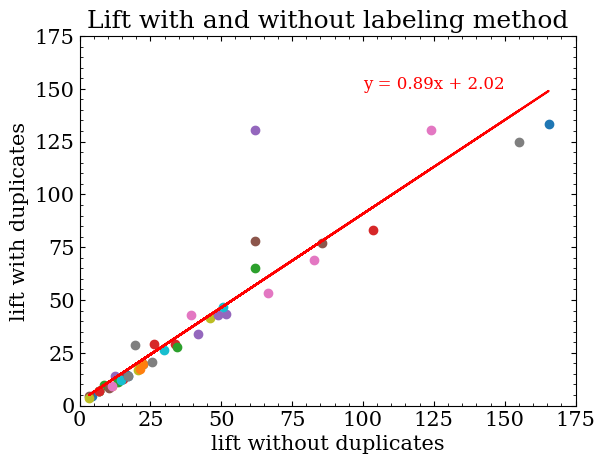

In [37]:
#Compares the lift of the cheat method to the lift of the method without the repeats
plt.figure()
x_values = []
y_values = []
count = 0
for rule in rulesidk:
    for rules in rulesstpl:
        if (rules == rule):
            count+=1
            x_values.append(rules.lift)
            y_values.append(rule.lift)
            plt.plot(rules.lift, rule.lift, marker='o', linestyle='none')
plt.xlabel('lift without duplicates')
plt.ylabel('lift with duplicates')
plt.title('Lift with and without labeling method')
plt.xlim(0, 175)
plt.ylim(0, 175)
print('count = ' + str(count))
x_array = np.array(x_values)
y_array = np.array(y_values)
m, b = np.polyfit(x_array, y_array, 1)
plt.plot(x_array, m*x_array+b, color='red', label='Line of Best Fit')
equation = f"y = {m:.2f}x + {b:.2f}"
plt.text(100, 150, equation, fontsize=12, color='red')
plt.show()

count = 48


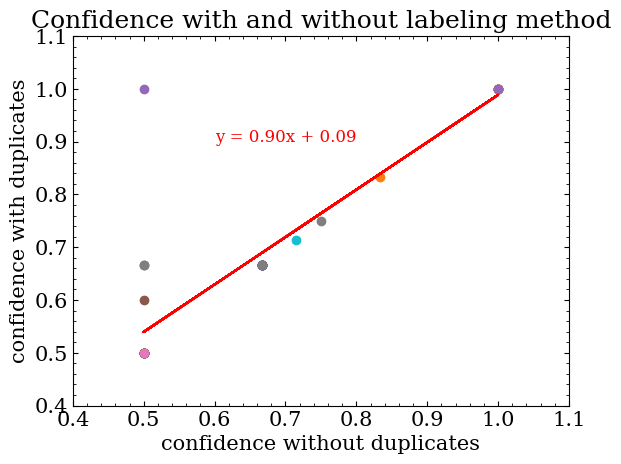

In [39]:
#Compares the confidence of the cheat method to the confidence of the method without the repeats
plt.figure()
x_conf = []
y_conf = []
count = 0
for rule in rulesidk:
    for rules in rulesstpl:
        if (rules == rule):
            count+=1
            x_conf.append(rules.confidence)
            y_conf.append(rule.confidence)
            plt.plot(rules.confidence, rule.confidence, marker='o', linestyle='none')
plt.xlabel('confidence without duplicates')
plt.ylabel('confidence with duplicates')
plt.title('Confidence with and without labeling method')
plt.xlim(.4, 1.1)
plt.ylim(.4, 1.1)
print('count = ' + str(count))
x_confa = np.array(x_conf)
y_confa = np.array(y_conf)
m, b = np.polyfit(x_confa, y_confa, 1)
plt.plot(x_confa, m*x_confa+b, color='red', label='Line of Best Fit')
equation2 = f"y = {m:.2f}x + {b:.2f}"
plt.text(0.6, .9, equation2, fontsize=12, color='red')
plt.show()

count = 48


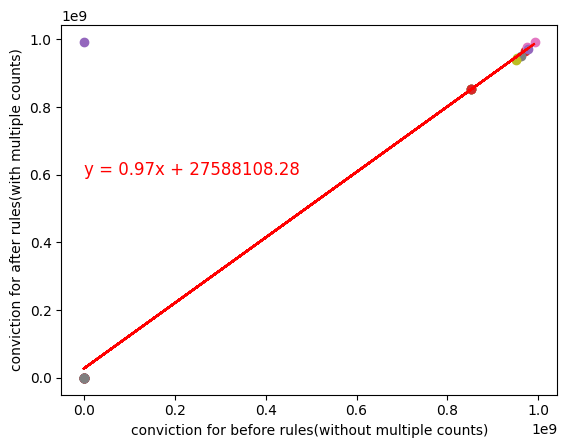

In [ ]:
#Compares the conviction of the cheat method to the conviction of the method without the repeats.
# what is conviction? Remember to look it up.
plt.figure()
x_cova = []
y_cova = []
count = 0
for rule in rulesidk:
    for rules in rulesstpl:
        if (rules == rule):
            count+=1
            x_cova.append(rules.conviction)
            y_cova.append(rule.conviction)
            plt.plot(rules.conviction, rule.conviction, marker='o', linestyle='none')
plt.xlabel('conviction for before rules(without multiple counts)')
plt.ylabel('conviction for after rules(with multiple counts)')
print('count = ' + str(count))
x_conva = np.array(x_cova)
y_conva = np.array(y_cova)
m, b = np.polyfit(x_conva, y_conva, 1)
plt.plot(x_conva, m*x_conva+b, color='red', label='Line of Best Fit')
equation3 = f"y = {m:.2f}x + {b:.2f}"
plt.text(0.6, .6e9, equation3, fontsize=12, color='red')
plt.show()


In [ ]:
#I think that I need to use the itemsets dictionary. What does it look like?
itemsetinverse, rulesinverse = apriori(MSplstAA, min_support= 2/len(onlyMS), min_confidence=.5)
print('There are ' + str((itemsetinverse).__len__())+ ' itemsets.')
mydic = itemsetinverse
#mydic[2]

There are 4 itemsets.


Text(0.8, 0.4, 'There are 56 points')

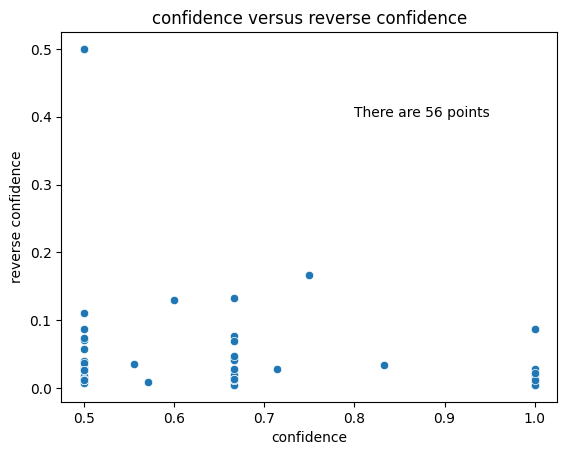

In [85]:
# figuring out how to find the inverse of the confidence for a given ruleset. Also, I need to figure out what this is called.
x_vals = []
y_vals = []
for ruleinv in rulesinverse:
    righths = ruleinv.rhs
    lefths = ruleinv.lhs
    whole = tuple(sorted(lefths.__add__(righths)))
    lsupp = ((itemsetinverse[lefths.__len__()])[lefths])/(onlyMS['hostname'].unique().__len__())
    rsupp = ((itemsetinverse[righths.__len__()])[righths])/(onlyMS['hostname'].unique().__len__())
    wsupp = ((itemsetinverse[whole.__len__()])[whole])/(onlyMS['hostname'].unique().__len__())
    confidence = wsupp/lsupp
    invconfidence = wsupp/rsupp
    x_vals.append(confidence)
    y_vals.append(invconfidence)
conf = sns.scatterplot(x= x_vals, y=y_vals)
conf.set_xlabel('confidence')
conf.set_ylabel('reverse confidence')
conf.set_title('confidence versus reverse confidence')
conf.annotate('There are ' + str(x_vals.__len__()) + ' points', (.8, .4))
    #This makes sense. The confidences are all above .5, which they should be, so I think that the code is working as intended.
    #also, why are they all so low?


In [ ]:
#returns the inverse of the confidence for a given rule, given a rule and a dataframe.
def get_invconfidence(rule, dataframe):
    righths = rule.rhs
    lefths = rule.lhs
    whole = tuple(sorted(lefths.__add__(righths)))
    rsupp = ((itemsetinverse[righths.__len__()])[righths])/(dataframe['hostname'].unique().__len__())
    wsupp = ((itemsetinverse[whole.__len__()])[whole])/(dataframe['hostname'].unique().__len__())
    return wsupp/rsupp

# determines the inverese of the confidence for every rule in the ruleset and filters by proportion if needed, given ruleset and a dataframe
def get_invconfidences(ruleset, dataframe):
    lists = []
    for rule in ruleset:
        righths = rule.rhs
        lefths = rule.lhs
        whole = tuple(sorted(lefths.__add__(righths)))
        rsupp = ((itemsetinverse[righths.__len__()])[righths])/(dataframe['hostname'].unique().__len__())
        wsupp = ((itemsetinverse[whole.__len__()])[whole])/(dataframe['hostname'].unique().__len__())
        if (wsupp/rsupp >= .5):
            lists.append(str(rule)+ ' invconf: ' + str(wsupp/rsupp))
    return lists

In [78]:
#testing the above functions to make sure that they seem accurate.
print(get_invconfidence(rulesinverse[3], onlyMS))
test = get_invconfidences(rulesinverse, onlyMS)
print(str(test.__len__()) + ' out of ' + str(rulesinverse.__len__()))
print(test)

0.013157894736842106
2 out of 56
['{M Temperate Sub-Saturn Medium-Short Orbital} -> {M Cold Sub-Saturn Medium-Long Orbital} (conf: 0.500, supp: 0.001, lift: 374.500, conv: 1.997) invconf: 0.5', '{M Cold Sub-Saturn Medium-Long Orbital} -> {M Temperate Sub-Saturn Medium-Short Orbital} (conf: 0.500, supp: 0.001, lift: 374.500, conv: 1.997) invconf: 0.5']
